![Screenshot 2026-08-19 194647.png](<attachment:Screenshot 2026-08-19 194647.png>)
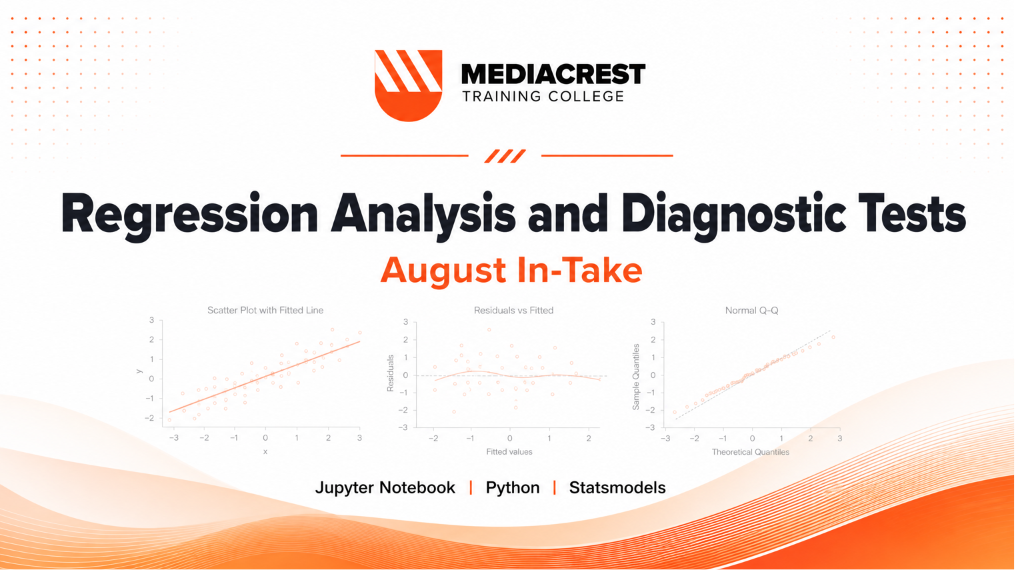

## **REGRESSION AND CORRELATION**

### **Correlational Analysis**

### **Load All the Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import warnings

#### **Filter the Warning and Set the Visualiozation Theme**

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format) # Equivalent to R's options(scipen=999)

print("Libraries loaded successfully.")

Libraries loaded successfully.


#### **Load the Mtcars data Set**

In [3]:
url_mtcars = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/mtcars.csv"
mtcars = pd.read_csv(url_mtcars, index_col=0)
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0000,6,160.0000,110,3.9000,2.6200,16.4600,0,1,4,4
Mazda RX4 Wag,21.0000,6,160.0000,110,3.9000,2.8750,17.0200,0,1,4,4
Datsun 710,22.8000,4,108.0000,93,3.8500,2.3200,18.6100,1,1,4,1
Hornet 4 Drive,21.4000,6,258.0000,110,3.0800,3.2150,19.4400,1,0,3,1
Hornet Sportabout,18.7000,8,360.0000,175,3.1500,3.4400,17.0200,0,0,3,2


#### **Basic Data Exploration**

In [4]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


##### **A Scatter Plot of Miles Per Gallon and Weight of the Car**

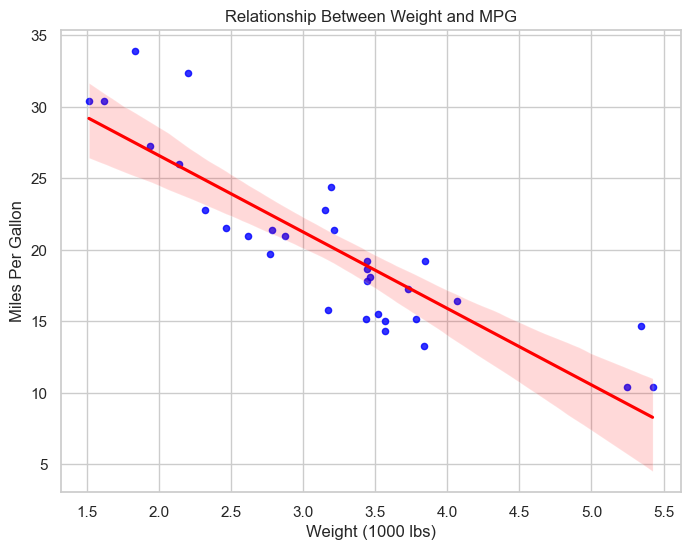

In [5]:
plt.figure(figsize=(8, 6))
sns.regplot(x = "wt", y = "mpg", data = mtcars,
            scatter_kws={'color': 'blue', 's': 20},
            line_kws = {'color': 'red'})
plt.title("Relationship Between Weight and MPG")
plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Miles Per Gallon")
plt.show()

#### **Null and Alternative Hypotheses**
* Null: There is no correlational Association between MPG and Weight, there is zero correlation
* Alternative: There is a correlational Association between MPG and Weight

#### **Pearson's Correlational Analysis (Parametric Test)**

In [6]:
r_pearson, p_pearson = stats.pearsonr(mtcars['wt'], mtcars['mpg'])
print(f"Pearson r: {r_pearson:.4f}, P-value: {p_pearson:.2e}")

Pearson r: -0.8677, P-value: 1.29e-10


#### **Spearmans Rank Order Correlation (Non Parametrics Test)**

In [7]:
r_pearson, p_pearson = stats.spearmanr(mtcars['wt'], mtcars['mpg'])
print(f"Pearson r: {r_pearson:.4f}, P-value: {p_pearson:.2e}")

Pearson r: -0.8864, P-value: 1.49e-11


### **CORRELATIONAL MATRIX**

In [8]:
num_vars = mtcars[['mpg', 'cyl', 'disp', 'hp', 'wt']]

In [9]:
corr_matrix = num_vars.corr(method='pearson')
display(corr_matrix.round(3))

,mpg,cyl,disp,hp,wt
mpg,1.0000,-0.8520,-0.8480,-0.7760,-0.8680
cyl,-0.8520,1.0000,0.9020,0.8320,0.7820
disp,-0.8480,0.9020,1.0000,0.7910,0.8880
hp,-0.7760,0.8320,0.7910,1.0000,0.6590
wt,-0.8680,0.7820,0.8880,0.6590,1.0000


#### **Visualize the Correlational Results**

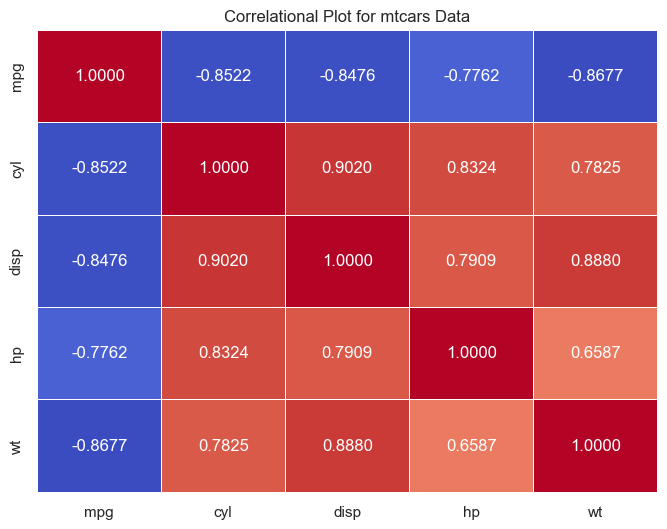

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True,
            cmap='coolwarm',
            fmt =".4f",
            linewidths = 0.5,
            cbar= False)
plt.title("Correlational Plot for mtcars Data")
plt.show()

### **SIMPLE LINEAR REGRESSION MODEL**

In [11]:
model_slr = smf.ols('mpg ~ wt', data=mtcars).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     91.38
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.29e-10
Time:                        19:20:04   Log-Likelihood:                -80.015
No. Observations:                  32   AIC:                             164.0
Df Residuals:                      30   BIC:                             167.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2851      1.878     19.858      0.0

A simple ordinary least squares (OLS) regression was conducted to examine the relationship between vehicle weight (*wt*) and fuel efficiency (*mpg*) using 32 observations. The regression model was statistically significant, *F*(1, 30) = 91.38, *p* < .001, explaining 75.3% of the variance in fuel efficiency (*R*² = .753, adjusted *R*² = .745).

Vehicle weight was a significant negative predictor of fuel efficiency, *b* = −5.34, *SE* = 0.56, *t*(30) = −9.56, *p* < .001, 95% CI [−6.49, −4.20]. This indicates that, on average, a one-unit increase in vehicle weight was associated with an estimated 5.34-unit decrease in miles per gallon (mpg). The intercept was also statistically significant, *b* = 37.29, *SE* = 1.88, *t*(30) = 19.86, *p* < .001, suggesting an estimated fuel efficiency of approximately 37.29 mpg when vehicle weight was zero, although this intercept has limited practical interpretation.

Diagnostic statistics indicated no strong evidence of substantial non-normality of the residuals, as both the Omnibus test (*p* = .225) and Jarque–Bera test (*p* = .301) were nonsignificant. However, the Durbin–Watson statistic of 1.25 suggests some positive residual autocorrelation may be present. Overall, the findings demonstrate a strong and statistically significant inverse association between vehicle weight and fuel efficiency.


### **Keynesian Theory of Income and Consumption**

In [12]:
df = pd.read_csv("income.csv")
df.head()

,Year,Income,Consumption
0,1950.0000,791.8000,733.2000
1,1951.0000,819.0000,748.7000
2,1952.0000,844.3000,771.4000
3,1953.0000,880.0000,802.5000
4,1954.0000,894.0000,822.7000


In [13]:
model_slr = smf.ols('Consumption ~ Income', data=df).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:            Consumption   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.359e+04
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.61e-50
Time:                        19:20:06   Log-Likelihood:                -155.71
No. Observations:                  36   AIC:                             315.4
Df Residuals:                      34   BIC:                             318.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.3737      9.629      1.181      0.2

An ordinary least squares (OLS) regression was conducted to examine the relationship between income and consumption, based on Keynesian consumption theory. The analysis used 36 observations and revealed a statistically significant regression model, *F*(1, 34) = 23,590, *p* < .001. The model explained approximately 99.9% of the variance in consumption (*R*² = .999, adjusted *R*² = .999), indicating an exceptionally strong linear relationship between income and consumption.

Income was a statistically significant positive predictor of consumption, *b* = 0.898, *SE* = 0.006, *t*(34) = 153.60, *p* < .001, 95% CI [0.886, 0.910]. Thus, a one-unit increase in income was associated with an estimated 0.898-unit increase in consumption, holding other factors constant. The estimated intercept was 11.37 (*SE* = 9.63), but it was not statistically significant, *t*(34) = 1.18, *p* = .246, 95% CI [−8.20, 30.94].

These findings provide strong empirical support for the central Keynesian proposition that consumption increases as income increases. In the Keynesian consumption function, (C = a + bY), where *C* represents consumption, *a* is autonomous consumption, *b* is the marginal propensity to consume (MPC), and *Y* represents income. The estimated income coefficient of 0.898 can therefore be interpreted as an MPC of approximately 0.90. This implies that households consume about 89.8% of each additional unit of income, while the remaining approximately 10.2% represents saving, assuming income is divided between consumption and saving.

The nonsignificant intercept suggests limited statistical evidence for autonomous consumption in this sample. However, the extremely high *R*² should be interpreted cautiously because the Durbin–Watson statistic (0.843) indicates possible positive serial correlation, which may affect standard errors and statistical inference. Overall, the results strongly support the Keynesian income–consumption relationship.


## **MULTIPLE LINEAR REGRESSION ANALYSIS**

In [14]:
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0000,6,160.0000,110,3.9000,2.6200,16.4600,0,1,4,4
Mazda RX4 Wag,21.0000,6,160.0000,110,3.9000,2.8750,17.0200,0,1,4,4
Datsun 710,22.8000,4,108.0000,93,3.8500,2.3200,18.6100,1,1,4,1
Hornet 4 Drive,21.4000,6,258.0000,110,3.0800,3.2150,19.4400,1,0,3,1
Hornet Sportabout,18.7000,8,360.0000,175,3.1500,3.4400,17.0200,0,0,3,2


In [17]:
model_mlr = smf.ols('mpg ~ wt + hp', data=mtcars).fit()
print(model_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.11e-12
Time:                        19:24:48   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:                      29   BIC:                             159.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2273      1.599     23.285      0.0

**Predictors:** 
* Weight of the Veehicle
* Horse Power

**Predicted Variable**
* Miles Per Gallon

**Equation:** $\hat{\text{MPG}} = 37.227 - 3.878(wt) - 0.032 (hp)$

#### **Prediction**

**Predicted MPG:** $\hat{\text{MPG}} = 37.227 - (3.878 \times 2.620) - (0.032 \times 110)$

**Predicted MPG=**  23.54664

**Residual=** 21.00 - 23.54664 = -2.54664

#### **Model Diagnostics**
##### **Multicollinearity and Influential Observations**
* **VIF (Variance Inflation Factor):** Values > 5 or 10 indicate high multicollinearity.
* **Cook's Distance:** Identifies influential observations. Threshold commonly set at $4/n$.

##### **1. Multicollinearity**

In [19]:
X_vif = mtcars[['wt', 'hp']].copy()
X_vif['const'] = 1 
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF']= [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
display(vif_data)

,feature,VIF
0,wt,1.7666
1,hp,1.7666
2,const,12.1615


##### **2. Cook's Distance and Influencial Observations**

In [20]:
influence = model_mlr.get_influence()
cooks_d = influence.cooks_distance[0]
mtcars['cooks_d'] = cooks_d
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cooks_d
rownames,,,,,,,,,,,,
Mazda RX4,21.0000,6,160.0000,110,3.9000,2.6200,16.4600,0,1,4,4,0.0159
Mazda RX4 Wag,21.0000,6,160.0000,110,3.9000,2.8750,17.0200,0,1,4,4,0.0055
Datsun 710,22.8000,4,108.0000,93,3.8500,2.3200,18.6100,1,1,4,1,0.0207
Hornet 4 Drive,21.4000,6,258.0000,110,3.0800,3.2150,19.4400,1,0,3,1,0.0000
Hornet Sportabout,18.7000,8,360.0000,175,3.1500,3.4400,17.0200,0,0,3,2,0.0003


In [24]:
mtcars.head(32)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cooks_d
rownames,,,,,,,,,,,,
Mazda RX4,21.0000,6,160.0000,110,3.9000,2.6200,16.4600,0,1,4,4,0.0159
Mazda RX4 Wag,21.0000,6,160.0000,110,3.9000,2.8750,17.0200,0,1,4,4,0.0055
Datsun 710,22.8000,4,108.0000,93,3.8500,2.3200,18.6100,1,1,4,1,0.0207
Hornet 4 Drive,21.4000,6,258.0000,110,3.0800,3.2150,19.4400,1,0,3,1,0.0000
Hornet Sportabout,18.7000,8,360.0000,175,3.1500,3.4400,17.0200,0,0,3,2,0.0003
Valiant,18.1000,6,225.0000,105,2.7600,3.4600,20.2200,1,0,3,1,0.0216
Duster 360,14.3000,8,360.0000,245,3.2100,3.5700,15.8400,0,0,3,4,0.0126
Merc 240D,24.4000,4,146.7000,62,3.6900,3.1900,20.0000,1,0,4,2,0.0168
Merc 230,22.8000,4,140.8000,95,3.9200,3.1500,22.9000,1,0,4,2,0.0022


In [21]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mpg      32 non-null     float64
 1   cyl      32 non-null     int64  
 2   disp     32 non-null     float64
 3   hp       32 non-null     int64  
 4   drat     32 non-null     float64
 5   wt       32 non-null     float64
 6   qsec     32 non-null     float64
 7   vs       32 non-null     int64  
 8   am       32 non-null     int64  
 9   gear     32 non-null     int64  
 10  carb     32 non-null     int64  
 11  cooks_d  32 non-null     float64
dtypes: float64(6), int64(6)
memory usage: 4.3+ KB


In [22]:
threshold = 4 / len(mtcars)
threshold

0.125

In [23]:
threshold = 4 / 32
threshold

0.125

In [25]:
influential_obs = mtcars[mtcars['cooks_d'] > threshold].index
print(f"\nInfluential observations (Cook's D > {threshold:.3f}): {influential_obs.tolist()}")


Influential observations (Cook's D > 0.125): ['Chrysler Imperial', 'Fiat 128', 'Toyota Corolla', 'Maserati Bora']


#### **Re-Estimate the Model Without Influential Observations**

In [26]:
mtcars_no_inf = mtcars.drop(influential_obs)
mtcars_no_inf.head(30)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cooks_d
rownames,,,,,,,,,,,,
Mazda RX4,21.0000,6,160.0000,110,3.9000,2.6200,16.4600,0,1,4,4,0.0159
Mazda RX4 Wag,21.0000,6,160.0000,110,3.9000,2.8750,17.0200,0,1,4,4,0.0055
Datsun 710,22.8000,4,108.0000,93,3.8500,2.3200,18.6100,1,1,4,1,0.0207
Hornet 4 Drive,21.4000,6,258.0000,110,3.0800,3.2150,19.4400,1,0,3,1,0.0000
Hornet Sportabout,18.7000,8,360.0000,175,3.1500,3.4400,17.0200,0,0,3,2,0.0003
Valiant,18.1000,6,225.0000,105,2.7600,3.4600,20.2200,1,0,3,1,0.0216
Duster 360,14.3000,8,360.0000,245,3.2100,3.5700,15.8400,0,0,3,4,0.0126
Merc 240D,24.4000,4,146.7000,62,3.6900,3.1900,20.0000,1,0,4,2,0.0168
Merc 230,22.8000,4,140.8000,95,3.9200,3.1500,22.9000,1,0,4,2,0.0022


In [27]:
model_mlr2 = smf.ols('mpg ~ wt + hp', data= mtcars_no_inf).fit()
print(model_mlr2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     102.9
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           8.60e-13
Time:                        20:06:00   Log-Likelihood:                -54.076
No. Observations:                  28   AIC:                             114.2
Df Residuals:                      25   BIC:                             118.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.3375      1.255     28.956      0.0

#### **Prediction using the Newly Estimated Model**

**Predicted MPG:** $\hat{\text{MPG}} = 36.3375 - (3.7517 \times 2.620) - (0.0332 \times 110)$

**Predicted MPG=**  22.856

**Observed MPG** = 21.000

**Residual=** 21.00 - 23.54664 = -1.856

### **Testing the Assumptions of Classical Linear Regression Model**

1. **Normality of the Residuals:** Shapiro Wilks Test and Anderson-Darling Test
2. **Homoscedasticity:** The constant variance of the residuals/ error term: Breusch Pagan Test
3. **Independence of the Residuals/Autocorrelation Test:** Durbin Watson Test

In [28]:
residuals = model_mlr2.resid
residuals

rownames
Mazda RX4             -1.8518
Mazda RX4 Wag         -0.8951
Datsun 710            -1.7423
Hornet 4 Drive         0.7805
Hornet Sportabout      1.0852
Valiant               -1.7665
Duster 360            -0.5004
Merc 240D              2.0913
Merc 230               1.4381
Merc 280              -0.1432
Merc 280C             -1.5432
Merc 450SE             1.3149
Merc 450SL             0.9393
Merc 450SLC           -0.9731
Cadillac Fleetwood     0.5729
Lincoln Continental    1.5581
Honda Civic            1.8499
Toyota Corona         -2.3654
Dodge Challenger      -2.6457
AMC Javelin           -3.2646
Camaro Z28            -0.4875
Pontiac Firebird       3.1046
Fiat X1-9              0.4158
Porsche 914-2          0.7159
Lotus Europa           3.4948
Ford Pantera L         0.1304
Ferrari Dino          -0.4285
Volvo 142E            -0.8847
dtype: float64

#### **1. Normality Test**

* Null hypothesis: Residuals Follow a Normal Distribution
* Alternative Hypothesis: Residuals Deviates from a Normal Distribution

##### **Decision Criteria:** 
**Reject** the Null Hypothesis if and only if the p-value < 0.05

In [32]:
stat_sw, p_sw = stats.shapiro(residuals)
print(f"Shapiro Wilks Test: W = {stat_sw:.5f}, p-value = {p_sw:.5f}")

Shapiro Wilks Test: W = 0.98710, p-value = 0.97385


From the Results above, we fail to reject the null hypothesis and conclude that the residuals follow a normal distribution

In [33]:
stat_ad, crit_ad, sig_ad = stats.anderson(residuals, dist='norm')
print(f"Anderson-Darling Test: {stat_ad:.5f}")

Anderson-Darling Test: 0.13549


#### **Q-Q Plot and Histogram for Distribution of Residuals**

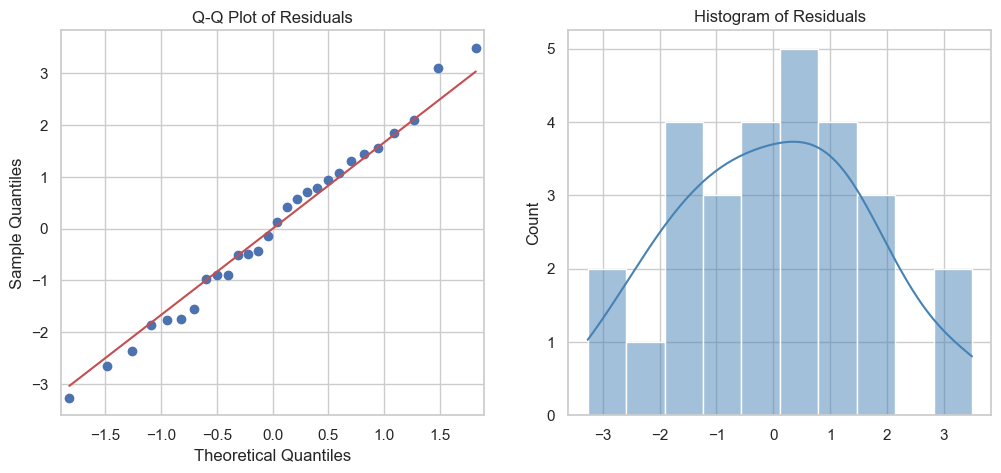

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title("Q-Q Plot of Residuals")

sns.histplot(residuals, 
             bins=10, 
             kde=True, 
             ax=ax[1], 
             color='steelblue')
ax[1].set_title("Histogram of Residuals")

plt.show()

#### **2. Homoscedasticity: Breusch Pagan Test**

**Null hypothesis:** There is a constant variance of the residuals (Preferred Decision)

**Alternative Hypothesis:** The variance of the residuals is non-constant (Unwanted Decision)

##### **Decision Criteria**

**Reject** the Null hypothesis if and only if the p-value < 0.05

In [36]:
bp_test = het_breuschpagan(residuals, model_mlr2.model.exog)
print(f"\nBreusch Pagan Test: BP = {bp_test[0]:.5f}, p-value = {bp_test[1]:5f}")


Breusch Pagan Test: BP = 1.34296, p-value = 0.510951


#### **3. Independence of the Residuals: Durbin Watson**

In [37]:
dw_test = durbin_watson(residuals)
print(f"Durbin-Watson Test: {dw_test:.5f}")

Durbin-Watson Test: 1.41731
